In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.utils import *
from stericheight.data_handler import *
from stericheight.plotting_fns import *
from stericheight.steric_height import *

pf = PlottingFns()

In [3]:
import cartopy.crs as ccrs
import xarray as xr
import cmocean
import matplotlib.patches as mpatches

In [4]:
# helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

In [5]:
#dot_ds = DOT().ds
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [6]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

sha_ds_sla0 = StericHeight(ssh_ref='DOT',
                      ssh=sla0,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [7]:
extent = [66,81.5,-70,-66]

In [8]:
# crop datasets to chosen area
sla = crop_to_extent(sla,extent)
sla0 = crop_to_extent(sla0,extent)
lwe = crop_to_extent(lwe_ds,extent).lwe_thickness
dot = crop_to_extent(dot_ds,extent).dot
sha_dot = crop_to_extent(sha_ds_dot,extent).sha
sha_sla = crop_to_extent(sha_ds_sla,extent).sha
sha_sla0 = crop_to_extent(sha_ds_sla0,extent).sha


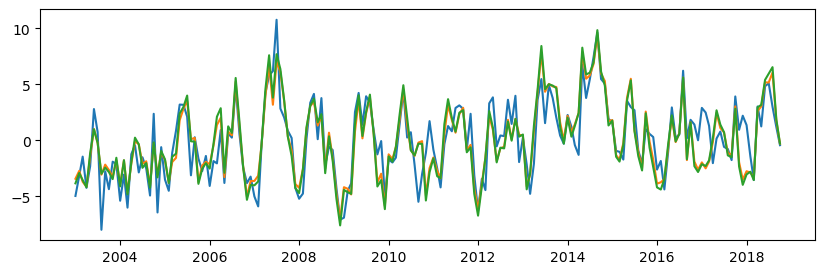

In [9]:
start = sla.time[0]
end = dot.time[-1]

sla_cropped = sla.sel(time=slice(start,end))
sla_adjusted = sla_cropped - sla_cropped.mean('time')

sla0_cropped = sla0.sel(time=slice(start,end))
sla0_adjusted = sla0_cropped - sla0_cropped.mean('time')

dot_cropped = dot.sel(time=slice(start,end))
dot_adjusted = dot_cropped - dot_cropped.mean('time')

fig,ax = plt.subplots(figsize=(10,3))
ax.plot(dot_adjusted.time, dot_adjusted.mean(['latitude','longitude']))
ax.plot(sla_adjusted.time, sla_adjusted.mean(['latitude','longitude']))
ax.plot(sla0_adjusted.time, sla0_adjusted.mean(['latitude','longitude']))


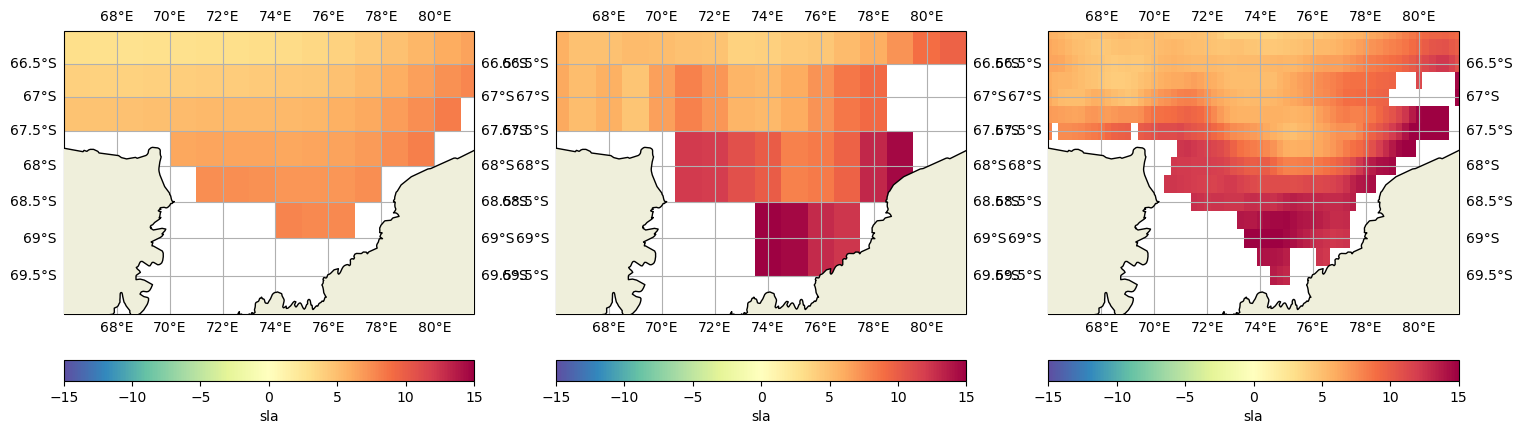

In [11]:
fig, ax = plt.subplots(1,3, figsize=(18,6),subplot_kw={"projection":ccrs.Mercator()})
pf.sp(ax[0],dot_adjusted.sel(time=pd.Timestamp(2013,6,1),method='nearest'),cbar='sla',vmin=-15,vmax=15,extent=extent)
pf.sp(ax[1],sla_adjusted.sel(time=pd.Timestamp(2013,6,1),method='nearest'),cbar='sla',vmin=-15,vmax=15,extent=extent)
pf.sp(ax[2],sla0_adjusted.sel(time=pd.Timestamp(2013,6,1),method='nearest'),cbar='sla',vmin=-15,vmax=15,extent=extent)



In [34]:
sha_dot_seasons = season_split(sha_dot)
sha_sla_seasons = season_split(sha_sla)
sha_sla0_seasons = season_split(sha_sla0)


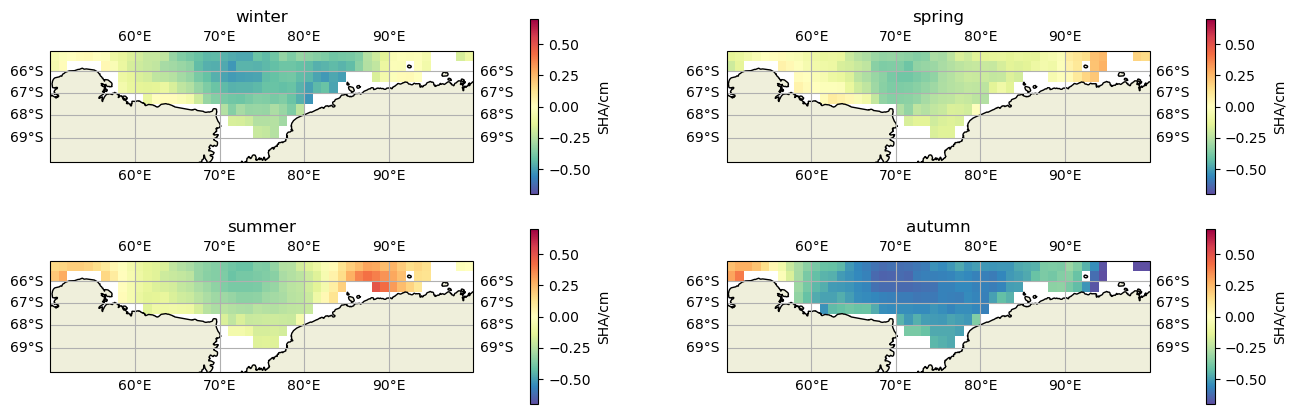

In [30]:
fig, ax = plt.subplots(2,2,figsize=(16,5), subplot_kw={"projection":ccrs.Mercator()})
pfsp = lambda ax, season: pf.sp(ax,get_trend(sha_dot_seasons[season]),title=season,extent=extent,cbar="SHA/cm",vmin=-0.7,vmax=0.7,cbar_orientation='vertical',land_zorder=2)
pfsp(ax[0][0],'winter')
pfsp(ax[0][1],'spring')
pfsp(ax[1][0],'summer')
pfsp(ax[1][1],'autumn')

# for k,v in glaciers.items():
#     if (v[0] > extent[0]) & (v[0] < extent[1]):  
#         for a in ax.flat:
#             a.text(v[0],v[1],k,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))




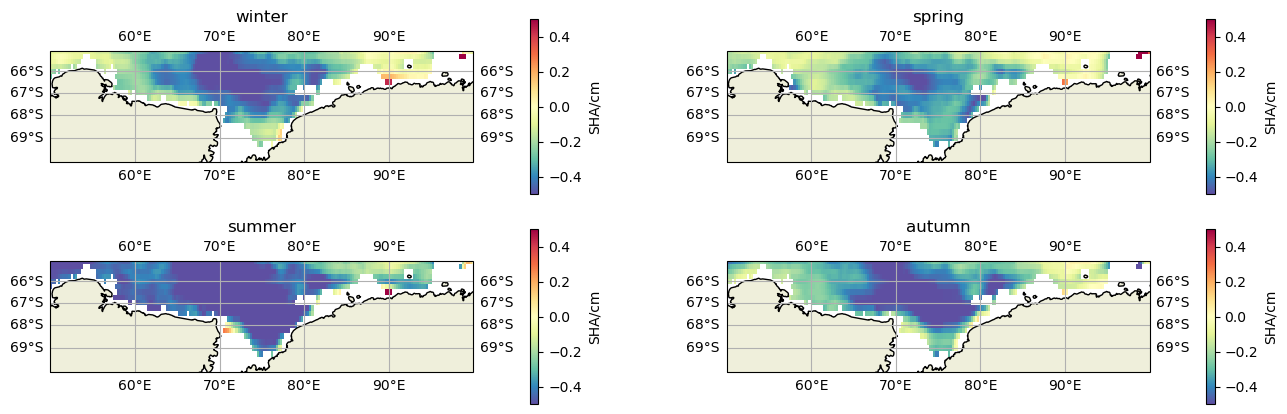

In [36]:
fig, ax = plt.subplots(2,2,figsize=(16,5), subplot_kw={"projection":ccrs.Mercator()})
pfsp = lambda ax, season: pf.sp(ax,get_trend(sha_sla0_seasons[season]),title=season,extent=extent,cbar="SHA/cm",vmax=0.5,cbar_orientation='vertical',land_zorder=2)
pfsp(ax[0][0],'winter')
pfsp(ax[0][1],'spring')
pfsp(ax[1][0],'summer')
pfsp(ax[1][1],'autumn')

# for k,v in glaciers.items():
#     if (v[0] > extent[0]) & (v[0] < extent[1]):   
#         for a in ax.flat:
#             a.text(v[0],v[1],k,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))

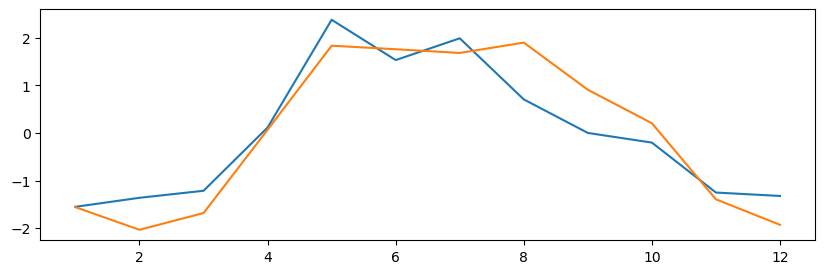

In [39]:
# compare climatologies
dot_cmt = dot_adjusted.groupby('time.month').mean()
sla_cmt = sla_adjusted.groupby('time.month').mean()
fig,ax = plt.subplots(figsize=(10,3))
ax.plot(dot_cmt.month,dot_cmt.mean(['latitude','longitude']))
ax.plot(dot_cmt.month,sla_cmt.mean(['latitude','longitude']))

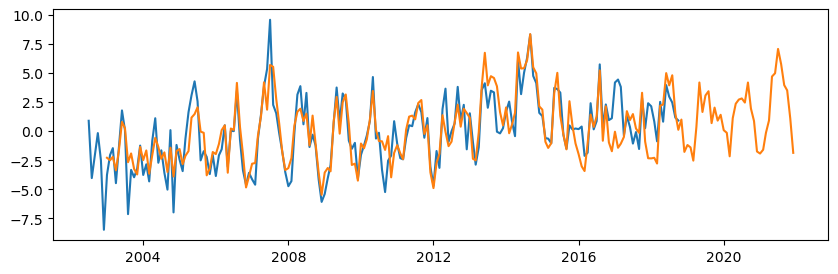

In [41]:
sla_adjusted_full = sla - sla_cropped.mean('time')
dot_adjusted_full = dot - dot_cropped.mean('time')

fig,ax = plt.subplots(figsize=(10,3))
ax.plot(dot_adjusted_full.time, dot_adjusted_full.mean(['latitude','longitude']))
ax.plot(sla_adjusted_full.time, sla_adjusted_full.mean(['latitude','longitude']))